In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Load dataset

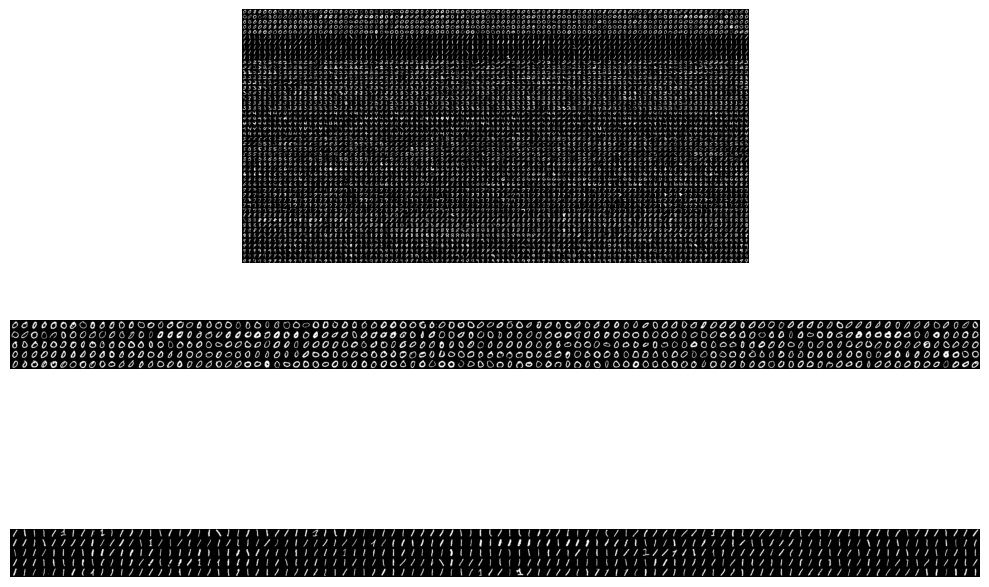

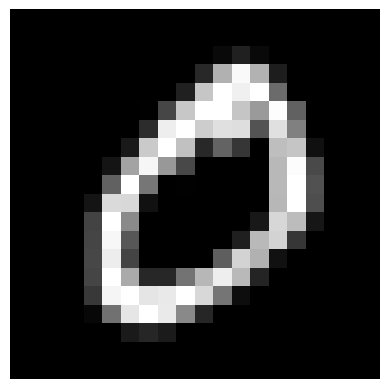

In [2]:
img = cv.imread('../../../class.vision/dataset/digits.png', 0)
DIGIT_SIZE = 20
SECTION_ROWS, SECTION_COLS = 5, 100

plt.figure(figsize=(10,7))
plt.subplot(311); plt.imshow(img, cmap='gray'); plt.axis('off');
plt.subplot(312); plt.imshow(img[0: DIGIT_SIZE*SECTION_ROWS, :], cmap='gray'); plt.axis('off');
plt.subplot(313); plt.imshow(img[DIGIT_SIZE*SECTION_ROWS: DIGIT_SIZE*SECTION_ROWS*2, :], cmap='gray'); plt.axis('off');
plt.tight_layout(); plt.show();
plt.subplot(111); plt.imshow(img[0:DIGIT_SIZE, 0:DIGIT_SIZE], cmap='gray'); plt.axis('off');

## Splitting

In [3]:
print("img shape:", img.shape)

img shape: (1000, 2000)


cell shape: (20, 20)


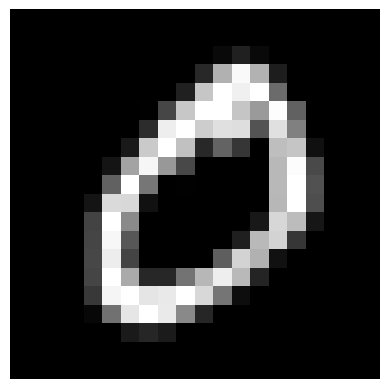

In [4]:
rows = np.vsplit(img, img.shape[0] / DIGIT_SIZE)
cells_of_sec = np.hsplit(rows[0], 100)
plt.imshow(cells_of_sec[0], cmap='gray'); plt.axis('off');
print("cell shape:", cells_of_sec[0].shape)

cells shape: (5000, 20, 20)


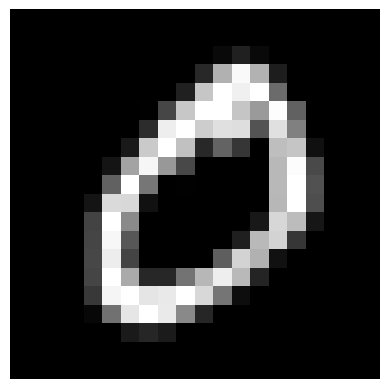

In [35]:
cells = np.reshape(img, (50, 20, 100, 20)).transpose(0,2,1,3).reshape(-1, 20, 20)
print("cells shape:", cells.shape)

plt.imshow(cells[0], cmap='gray'); plt.axis('off');

## Prepare data

(5000, 1)


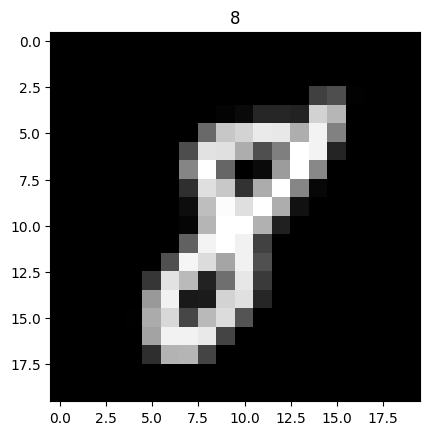

In [46]:
labels = np.arange(10)
Y = np.repeat(labels,SECTION_ROWS*SECTION_COLS)
i = 4000
plt.imshow(cells[i], cmap='gray'); plt.title(Y[i])

X = cells.copy()
Y = Y[:, np.newaxis]
print(Y.shape)

Text(0.5, 1.0, '[1]')

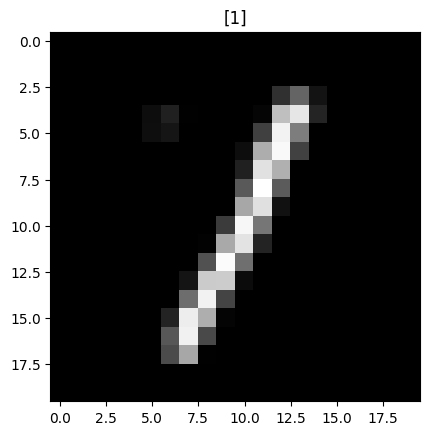

In [56]:
rng = np.random.default_rng()
indices = rng.permutation(len(X))

X = X[indices]
Y = Y[indices]

i = 4000
plt.imshow(X[i], cmap='gray'); plt.title(Y[i])

In [64]:
X = X.reshape(-1, 20*20).astype(np.float32)

In [65]:
print(X.shape)
print(Y.shape)

(5000, 400)
(5000, 1)


In [66]:
X_train, X_test = np.vsplit(X, 2)
Y_train, Y_test = np.vsplit(Y, 2)
print(X_train.dtype)
print(Y_train.dtype)

float32
int64


## Train

In [67]:
knn = cv.ml.KNearest_create()
knn.train(X_train, cv.ml.ROW_SAMPLE, Y_train)

True

In [68]:
ret,result,neighbours,dist = knn.findNearest(X_test,k=5)
# Now we check the accuracy of classification
# For that, compare the result with test_labels and check which are wrong
matches = result==Y_test
correct = np.count_nonzero(matches)
accuracy = correct*100.0/result.size
print( accuracy )

92.64
